# Discharge timeseries
***

***Author:** Chus Casado Rodríguez*<br>
***Date:** 11-02-2025*<br>

**Introduction**<br>
This notebook analyses the daily time series of river discharge to the oceans, and it produces time series of annual and monthly anomalies.

**Output**<br>
* *discharge_annual_anomaly_by_ocean.csv*: yearly time series of discharge anomaly (km3/year) from 1979 to 2024 compared with the period 1991-2020, disaggregated by ocean.
* *discharge_montly_anomaly_by_ocean.nc*: monthly time series of discharge anomaly (km3/year) from 1979 to 2024 compared with the monthly averages in the period 1991-2020, disaggregated by ocean.
* *discharge_seasonality_by_ocean.nc*:  monthly climatology of dicharge (mean and standard deviation) for the period 1991-2020, and the monthly values in 2024, disaggregated by ocean.

In [58]:
import os
os.environ['USE_PYGEOS'] = '0'
import numpy as np
import pandas as pd
import geopandas as gpd
# from shapely.geometry import Point
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.auto import tqdm
from datetime import datetime

## Configuration

In [2]:
VAR = 'discharge'

# inputs
PATH_IN = Path('../data/GloFAS') / VAR
POINTS_FILE = PATH_IN / 'outlets_5000km2_ocean.shp'
TS_FILE = PATH_IN / f'{VAR}_outlets.nc'

# outputs
PATH_OUT = Path('../results') / VAR
PATH_PLOT = PATH_OUT / 'plots'
PATH_PLOT.mkdir(parents=True, exist_ok=True)

# climatology
START = datetime(1991, 1, 1)
END = datetime(2020, 12, 31)

In [3]:
map_variables = {
    'runoff': 'rowe',
    'discharge': 'dis24'
}

var_shortname = map_variables[VAR]

## Data

### River outlets

In [5]:
# load modified river outlets
outlets = gpd.read_file(POINTS_FILE).set_index('ID', drop=True)

### Discharge time series

In [6]:
# load extracted discharge time series at the outlets
dis = xr.open_dataset(TS_FILE)[var_shortname]

# rename or drop variables
dis = dis.drop_vars('surface', errors='ignore')
dis = dis.rename({'valid_time': 'time'})

# convert time convention to beginning-of-timestep
dis['time'] = dis['time'] - pd.Timedelta(days=1)

## Processing

### Interannual variability of freshwater discharge
Annual time series and monthly anomalies of freshwater discharge ($\frac{km^3}{yr}$) into the 4 oceans.

In [ ]:
dis_year = {}

for ocean in tqdm(outlets.ocean.unique()):

    # rivers draining to that ocean basin
    IDs = outlets[outlets.ocean == ocean].index.tolist()

    # compute time series of total annual discharge into that ocean
    serie = dis.sel(ID=IDs).sum('ID').resample(time='1Y').mean(skipna=True).to_pandas()

    # convert from m3/s to km3/year
    serie *= 3600 * 24 * 365 * 1e-9

    dis_year[ocean] = serie

# convert to DataFrame
dis_year = pd.DataFrame.from_dict(dis_year)
# set index to the first day of the year
dis_year.index = [idx.year for idx in dis_year.index]

# compute anomaly
annual_anomaly = dis_year - dis_year.loc[START.year:END.year].mean(axis=0)
annual_anomaly.index.name = 'year'

# change index to July 1st
annual_anomaly.index = [datetime(year, 7, 1) for year in annual_anomaly.index]

### Monthly time series of discharge

In [9]:
dis_month = {}
for ocean in tqdm(outlets.ocean.unique()):

    # rivers draining to that ocean basin
    IDs = outlets[outlets.ocean == ocean].index.tolist()

    # compute time series of total annual discharge into that ocean
    serie = dis.sel(ID=IDs).sum('ID').resample(time='1M').mean(skipna=True).to_pandas()

    # convert from m3/s to km3/year
    serie *= 3600 * 24 * 365 * 1e-9

    dis_month[ocean] = serie

# convert to DataFrame
dis_month = pd.DataFrame.from_dict(dis_month)

# set index to the first day of the month
dis_month.index = [datetime(idx.year, idx.month, 1) for idx in dis_month.index]
dis_month['year'] = dis_month.index.year
dis_month['month'] = dis_month.index.month

# convert to DataArray
ls = []
for ocean in tqdm(outlets.ocean.unique()):
    # pivot the ocean time series
    df = dis_month.pivot(index='month', columns='year', values=ocean)
    
    # convert to xarray.DataArray
    da = xr.DataArray(
        df.values, 
        dims=("month", "year"), 
        coords={
            "month": df.index,
            "year": df.columns,
        },
        name='monthly_discharge'
    )
    
    # add new coordinate: 'ocean'
    da = da.expand_dims(ocean=[ocean])
    
    ls.append(da)
    
# concatenate oceans
dis_month = xr.concat(ls, dim='ocean')

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

### Climatology vs last year

In [10]:
# climatology of monthly discharge
seasonality = xr.Dataset({
    'mean': dis_month.sel(year=slice(START.year, END.year)).mean('year'),
    'std': dis_month.sel(year=slice(START.year, END.year)).std('year')
})

In [11]:
# monthly discharge 2024
seasonality['2024'] = dis_month.sel(year=2024).drop_vars('year')

### Monthly anomalies

In [12]:
# compute
monthly_anomalies = dis_month - seasonality['mean']

## Plot

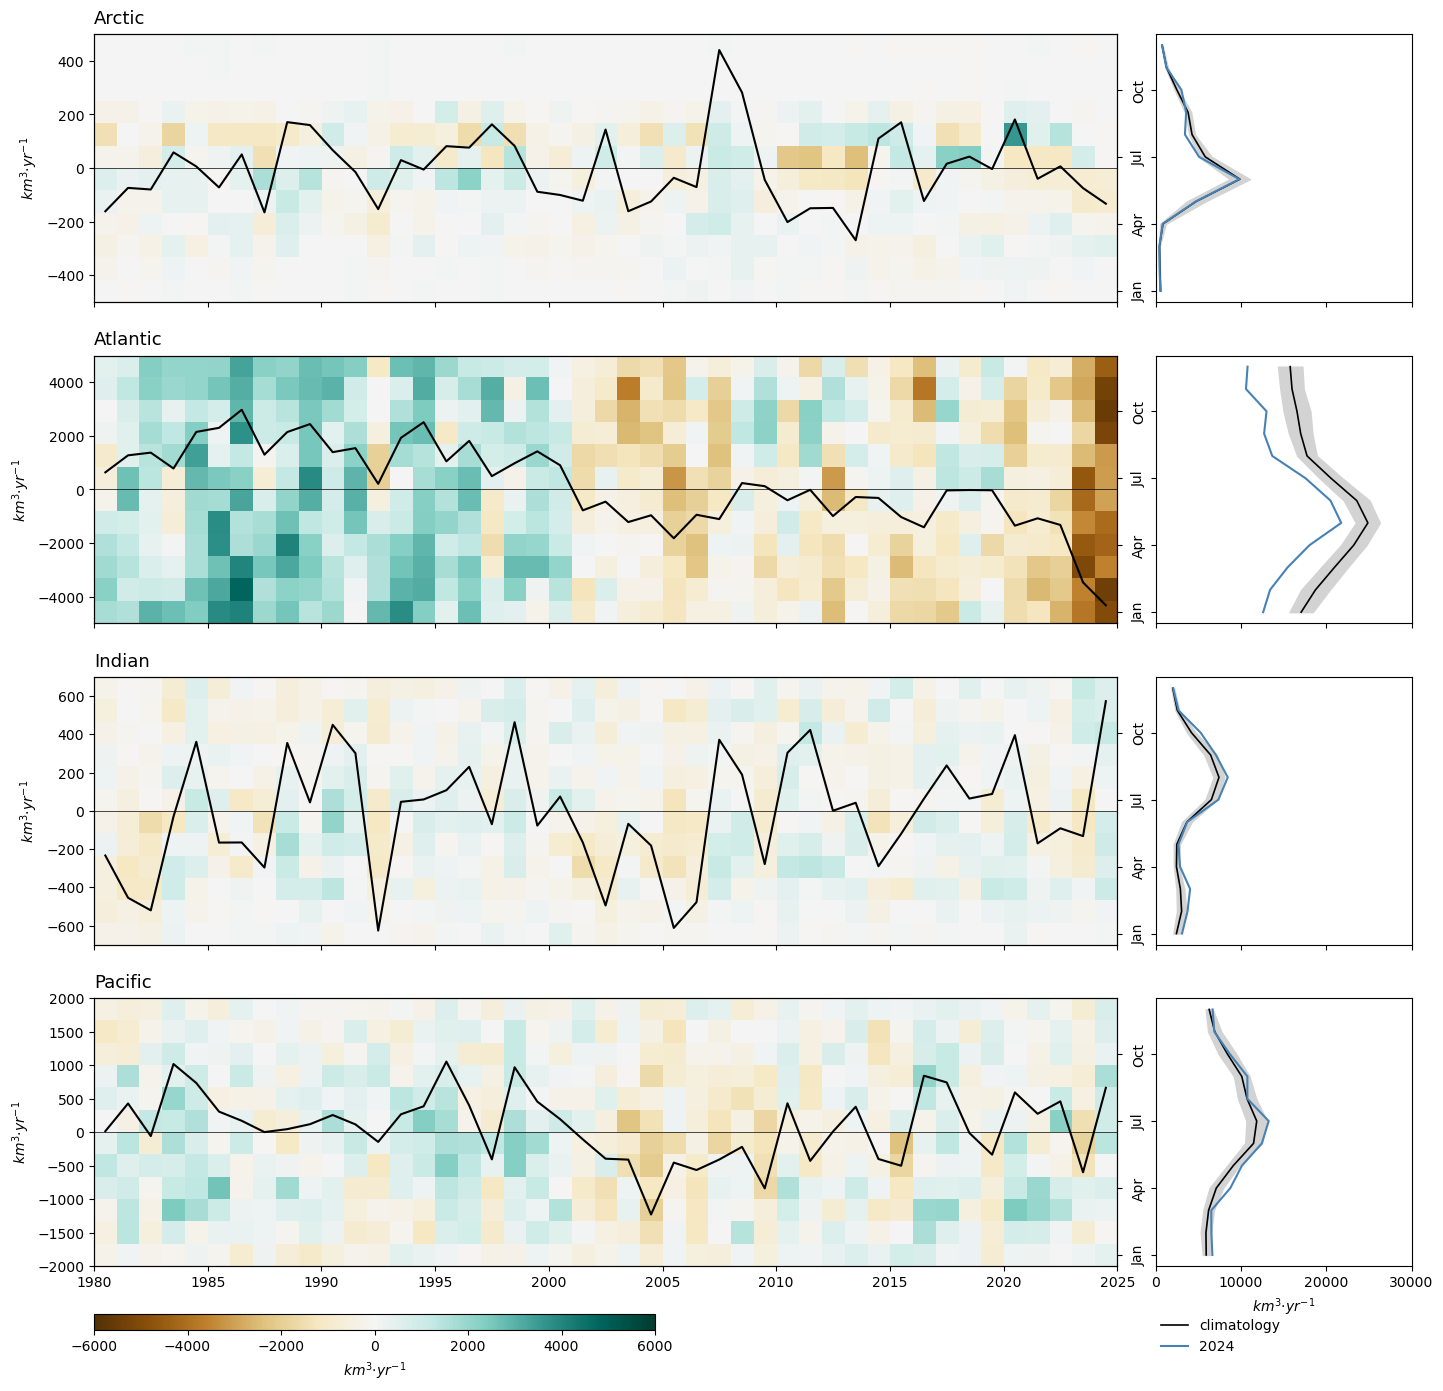

In [163]:
xlim = (datetime(1980, 1, 1), datetime(2025, 1, 1))
cmap = 'BrBG'
cb_min, cb_max = -6000, 6000

fig = plt.figure(figsize=(17, 16))
gs = gridspec.GridSpec(nrows=4, ncols=2, width_ratios=[4, 1], wspace=0.06)

# create subplots
axes_main = [fig.add_subplot(gs[i, 0]) for i in range(4)]
axes_side = [fig.add_subplot(gs[i, 1]) for i in range(4)]

for ax_main, ax_side, ocean in zip(axes_main, axes_side, sorted(outlets.ocean.unique())):
    
    # ===== MAIN TIME SERIES PLOT =====
    
    # ANNUAL ANOMALY
    
    anomaly = annual_anomaly[ocean]
    
    # lineplot of annual anomalies
    ax_main.plot(anomaly.loc[xlim[0]:xlim[-1]], c='k', lw=1.5, zorder=3)
    ax_main.axhline(0, c='k', lw=.5, zorder=2)
    
    vmax = max(abs(anomaly.max()), abs(anomaly.min()))
    exp = len(str(int(vmax))) - 1
    vmax = np.ceil(vmax / 10**exp) * 10**exp
    
    # MONTHLY ANOMALIES
    
    im = ax_main.imshow(
        monthly_anomalies.sel(ocean=ocean, year=slice(xlim[0].year, xlim[-1].year)).data,
        cmap=cmap,
        vmin=cb_min,
        vmax=cb_max,
        aspect='auto',
        extent=(0, 1, 0, 1),
        transform=ax_main.transAxes,
        zorder=1
        # cbar_kwargs={'label': r'$km^3·yr^{-1}$'}
    )
    
    # CONFIGURATION
    
    ax_main.set(
        xlim=xlim,
        ylim=(-vmax, vmax),
        ylabel=r'$km^3·yr^{-1}$',
    )
    ax_main.text(0, 1.04, ocean, fontsize=13, transform=ax_main.transAxes)
    if ax_main != axes_main[-1]:
        ax_main.set_xticklabels([])
        
    ax_main2 = ax_main.twinx()
    ax_main2.set(
        ylim=(.5, 12.5),
        yticks=range(1, 13, 3),
        yticklabels=[]
    )
        
    # ===== SEASONAL PLOT =====
    
    # extract monthly values
    mean = seasonality['mean'].sel(ocean=ocean).to_pandas()
    std = seasonality['std'].sel(ocean=ocean).to_pandas()
    target = seasonality['2024'].sel(ocean=ocean).to_pandas()
    
    ax_side.fill_betweenx(
        seasonality.month,
        mean - std,
        mean + std,
        color='lightgray',
        # alpha=.5,
        zorder=0
    )
    ax_side.plot(mean.values, mean.index, c='k', lw=1.2, zorder=1, label='climatology')
    ax_side.plot(target.values, target.index, c='steelblue', lw=1.5, zorder=2, label='2024')
    ax_side.set(
        xlim=(0, 3e4),
        ylim=(.5, 12.5),
        xticks=[0, 1e4, 2e4, 3e4],
        yticks=range(1, 13, 3),
    )
    ax_side.set_yticklabels(['Jan', 'Apr', 'Jul', 'Oct'], rotation=90, va='center', ha='right')
    if ax_side == axes_side[-1]:
        ax_side.set_xlabel(r'$km^3·yr^{-1}$')
    else:
        ax_side.set_xticklabels([])
        
# ===== Colorbar =====
cbar_ax = fig.add_axes([0.125, 0.07, 0.33, 0.01])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label(r'$km^3·yr^{-1}$')

# ===== Legend =====
handles, labels = ax_side.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.745, 0.085), frameon=False)

plt.savefig(PATH_PLOT / 'interannual_variability.jpg', dpi=300, bbox_inches='tight');

## Export

In [ ]:
# annual anomaly
output_file = PATH_OUT / f'{VAR}_annual_anomaly_by_ocean.csv'
annual_anomaly.to_csv(output_file, float_format='%.0f')
print(f'Annual anomalies of discharge saved in:\t{output_file}')

In [ ]:
# seasonality
output_file = PATH_OUT / f'{VAR}_seasonality_by_ocean.nc'
seasonality.to_netcdf(output_file)
print(f'Discharge seasonality saved in:\t{output_file}')

In [ ]:
# monthly anomalies
output_file = PATH_OUT / f'{VAR}_monthly_anomaly_by_ocean.nc'
monthly_anomalies.to_netcdf(output_file)
print(f'Discharge monthly anomalies saved in:\t{output_file}')